# Load NFLVerse Play By Play Data


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
##import NflVerse Data

pbp = pd.read_csv(
    "https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_2025.csv.gz",
    compression="gzip"
)

pbp.head(10)

/var/folders/v9/6485yjr56hz28z9sx2l8lkq80000gn/T/ipykernel_70385/2435075317.py:3: DtypeWarning: Columns (0: two_point_conv_result, 1: lateral_receiver_player_id, 2: lateral_receiver_player_name, 3: lateral_rusher_player_id, 4: lateral_rusher_player_name, 5: lateral_interception_player_id, 6: lateral_interception_player_name, 7: own_kickoff_recovery_player_id, 8: own_kickoff_recovery_player_name, 9: blocked_player_id, 10: blocked_player_name, 11: forced_fumble_player_2_team, 12: forced_fumble_player_2_player_id, 13: forced_fumble_player_2_player_name, 14: solo_tackle_2_team, 15: solo_tackle_2_player_id, 16: solo_tackle_2_player_name, 17: assist_tackle_3_player_id, 18: assist_tackle_3_player_name, 19: assist_tackle_3_team, 20: assist_tackle_4_player_id, 21: assist_tackle_4_player_name, 22: assist_tackle_4_team, 23: fumbled_2_player_id, 24: fumbled_2_player_name, 25: fumbled_2_team, 26: fumble_recovery_2_team, 27: fumble_recovery_2_player_id, 28: fumble_recovery_2_player_name, 29: safety_

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NaN,NaN,NaN,...,0,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.352700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,63,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.190052,NaN,NaN,NaN,NaN,NaN,0.511128,-51.112807
3,85,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,1,0,1.317340,0.939998,4.750889,3.0,0.666726,0.439110,0.668940,33.105969
4,115,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.694360,NaN,NaN,NaN,NaN,NaN,0.492038,50.796208
5,135,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-1.284150,NaN,NaN,NaN,NaN,NaN,0.716846,-71.684569
6,166,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,-0.840574,NaN,NaN,NaN,NaN,NaN,0.756109,-75.610864
7,188,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,ARI,away,NO,...,0,0,0.650589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,214,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NO,home,ARI,...,0,0,-0.194728,NaN,NaN,NaN,NaN,NaN,0.430873,-43.087283
9,243,2025_01_ARI_NO,2025090705,NO,ARI,REG,1,NO,home,ARI,...,0,0,-0.788527,1.147553,5.786526,4.0,0.664423,0.453707,0.614372,38.562781


In [12]:
pbp.columns

Index(['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team',
       'season_type', 'week', 'posteam', 'posteam_type', 'defteam',
       ...
       'out_of_bounds', 'home_opening_kickoff', 'qb_epa', 'xyac_epa',
       'xyac_mean_yardage', 'xyac_median_yardage', 'xyac_success', 'xyac_fd',
       'xpass', 'pass_oe'],
      dtype='str', length=372)

# Create Fourth Down Dataset

In [23]:
##Build fourth down df

fourth_downs = pbp[pbp['down'] == 4]
len(fourth_downs)

##Keep only 'go for it' attempts

go_for_it = fourth_downs[
    fourth_downs["play_type"].isin(["run", "pass"])
].copy()
len(go_for_it)
go_for_it.shape

(931, 372)

# Fourth Down Conversion Analytics

In [24]:
##Create our target variable

go_for_it["converted"] = (
    go_for_it["yards_gained"] >= go_for_it["ydstogo"]
).astype(int)

go_for_it[
    [
        "ydstogo",
        "yards_gained",
        "converted",
        "yardline_100",
        "score_differential"
    ]
].head(10)

,ydstogo,yards_gained,converted,yardline_100,score_differential
176,1,6.0,1,24.0,-7.0
180,10,0.0,0,18.0,-7.0
341,2,10.0,1,10.0,-15.0
378,1,4.0,1,63.0,0.0
471,1,0.0,0,5.0,-17.0
495,5,0.0,0,33.0,-17.0
504,1,3.0,1,34.0,17.0
567,1,2.0,1,48.0,-7.0
582,1,1.0,1,1.0,-7.0
664,5,0.0,0,39.0,-1.0


In [25]:
##How often do teams convert by distance?

conversion_rates = (
    go_for_it.groupby("ydstogo")["converted"]
    .mean()
    .round(2)
    .reset_index()

)

conversion_rates.head(10)

,ydstogo,converted
0,1,0.66
1,2,0.62
2,3,0.52
3,4,0.57
4,5,0.50
5,6,0.34
6,7,0.39
7,8,0.30
8,9,0.10
9,10,0.31


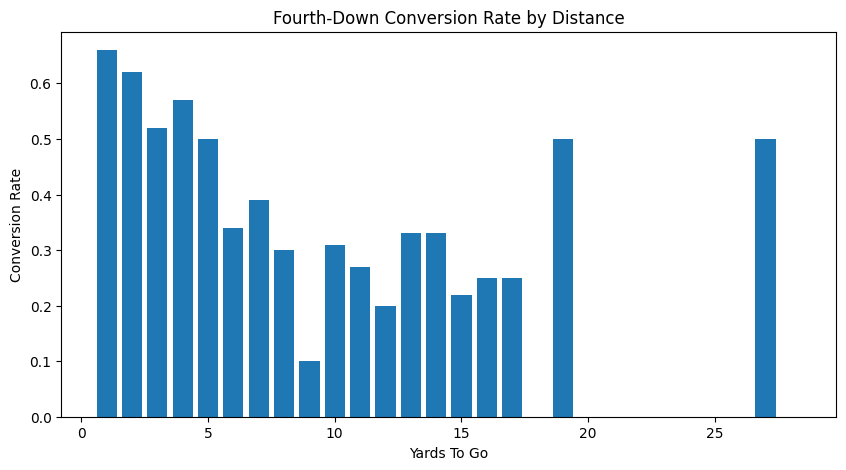

In [26]:
##Visualize our conversion data

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    conversion_rates["ydstogo"],
    conversion_rates["converted"]
)

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance")

plt.show()


The visualization above displays the fourth-down conversion rate by the distance required for a first down ('Yards To Go').

### Key Observations:
*   **Higher Conversion Rates for Shorter Distances:** As expected, teams show a higher propensity to convert fourth downs when the 'Yards To Go' is shorter, particularly within the 1-5 yard range. This aligns with typical strategic decisions in football.
*   **Anomalies at Longer Distances:** It's interesting to note the seemingly higher conversion rates at 18 and 27 yards to go, compared to the 5-15 yard range. While visually striking, these higher rates for longer distances (e.g., 18 and 27 yards) should be interpreted with caution. These attempts are likely much less frequent and may involve different play types or situations (e.g., Hail Mary passes, desperation plays) that don't represent a standard fourth-down attempt, thus skewing the conversion rate. The small sample size for these rare attempts can lead to volatile and potentially misleading conversion percentages.
*   **Decreasing Trend:** Generally, there's a clear decreasing trend in conversion rates as the 'Yards To Go' increases, indicating the increasing difficulty of converting longer distances.

In [27]:
conversion_summary = (
    go_for_it.groupby("ydstogo")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

conversion_summary.head(20)

,ydstogo,attempts,conversion_rate
0,1,379,0.662269
1,2,136,0.625000
2,3,102,0.519608
3,4,82,0.573171
4,5,50,0.500000
5,6,38,0.342105
6,7,18,0.388889
7,8,27,0.296296
8,9,10,0.100000
9,10,32,0.312500


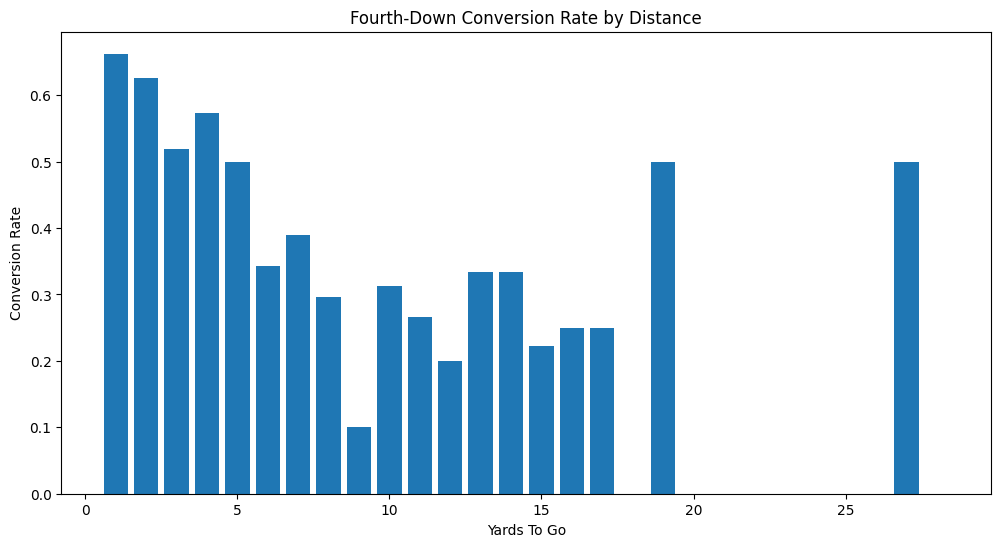

In [28]:
##New visualization

plt.figure(figsize=(12,6))

plt.bar(
    conversion_summary["ydstogo"],
    conversion_summary["conversion_rate"]
)

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance")

plt.show()

In [29]:
conversion_summary[
    conversion_summary["attempts"] >= 20
]

,ydstogo,attempts,conversion_rate
0,1,379,0.662269
1,2,136,0.625000
2,3,102,0.519608
3,4,82,0.573171
4,5,50,0.500000
5,6,38,0.342105
7,8,27,0.296296
9,10,32,0.312500


In [30]:
##Create zones of yards remaining to the endzone

go_for_it["field_zone"] = pd.cut(
    go_for_it["yardline_100"],
    bins=[0, 20, 50, 80, 100],
    labels=[
        "Red Zone",
        "Opponent Territory",
        "Midfield Area",
        "Own Territory"
    ]
)

##0-20 → close to scoring
##20-50 → opponent side
##50-80 → around midfield
##80-100 → backed up near own side

In [31]:
##Analyzing conversion rates by zone

zone_summary = (
    go_for_it.groupby("field_zone")
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

zone_summary

,field_zone,attempts,conversion_rate
0,Red Zone,258,0.573643
1,Opponent Territory,417,0.522782
2,Midfield Area,244,0.573770
3,Own Territory,12,0.666667


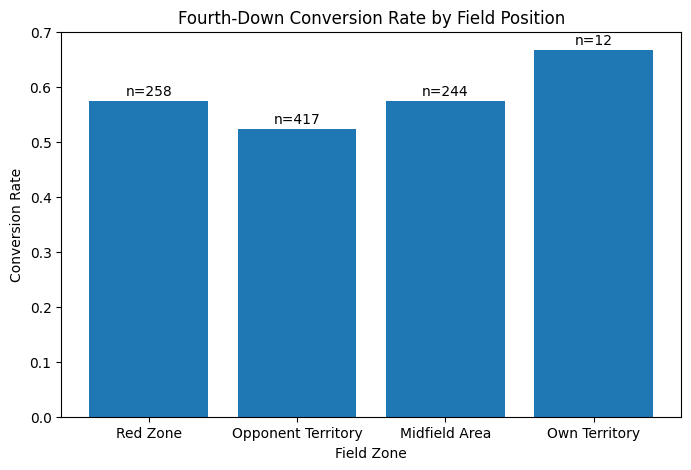

In [32]:
##Visualize

plt.figure(figsize=(8,5))

bars = plt.bar(
    zone_summary["field_zone"],
    zone_summary["conversion_rate"]
)

# Adding sample size labels
for bar, attempts in zip(bars, zone_summary["attempts"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={attempts}",
        ha='center'
    )

plt.ylabel("Conversion Rate")
plt.xlabel("Field Zone")
plt.title("Fourth-Down Conversion Rate by Field Position")

plt.show()

### Fourth-Down Conversion Rate by Field Position

The visualization above categorizes fourth-down attempts into four distinct field zones and shows their respective conversion rates along with the number of attempts (`n`).

#### Key Analytical Observations:

*   **Own Territory: High Efficiency, Low Volume:** The highest conversion rate is observed when teams attempt to convert a fourth down in their 'Own Territory' (66.7%). However, this also represents the smallest sample size with only 12 attempts. This suggests that coaches are extremely selective and likely only attempt these conversions in very favorable and high-confidence situations, or in desperate circumstances where the reward outweighs the risk.

*   **Red Zone vs. Midfield Area: Similar Effectiveness:** The 'Red Zone' and 'Midfield Area' show very similar conversion efficiencies, both hovering around 57%. This indicates that, despite the increased pressure and tighter defenses in the Red Zone, teams are converting fourth downs at a comparable rate to when they are around the middle of the field.

*   **Opponent Territory: Most Attempts, Lowest Rate:** 'Opponent Territory' sees the most fourth-down attempts (n=417) but surprisingly has the lowest conversion rate among all zones (52.3%). This suggests that while teams are most willing to 'go for it' on the opponent's side of the field, these situations are often more challenging than those selected in their own territory, or perhaps the yardage-to-go is frequently longer in these scenarios, contributing to a lower success rate. Additionally, the substantially larger sample size in Opponent Territory may provide a more statistically stable estimate of conversion efficiency compared to smaller-sample zones such as Own Territory. This aligns with the broader statistical principle that larger samples tend to produce more reliable estimates of underlying population behavior.

# Fourth Down Conversion Model

In [33]:
##Checking interaction between distance and field position

zone_distance_summary = (
    go_for_it.groupby(
        ["field_zone", "ydstogo"]
    )
    .agg(
        attempts=("converted", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

In [34]:
##Filtering weak sample sizes

zone_distance_summary = zone_distance_summary[
    zone_distance_summary["attempts"] >= 10
]

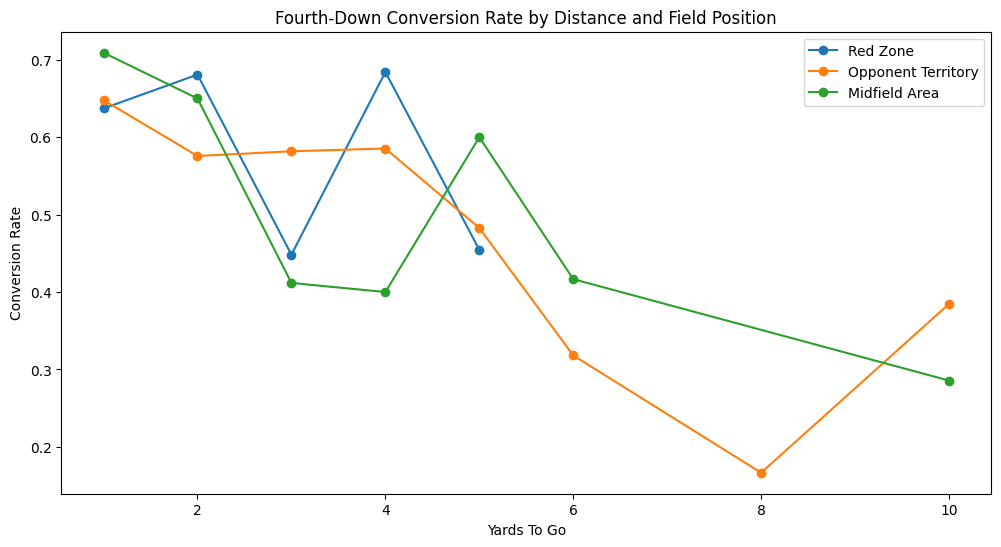

In [36]:
##Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for zone in zone_distance_summary["field_zone"].unique():

    zone_data = zone_distance_summary[
        zone_distance_summary["field_zone"] == zone
    ]

    plt.plot(
        zone_data["ydstogo"],
        zone_data["conversion_rate"],
        marker='o',
        label=zone
    )

plt.xlabel("Yards To Go")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Distance and Field Position")

plt.legend()

plt.show()

### Fourth-Down Conversion Rate by Distance and Field Zone

The graph shows that fourth-down attempts in the Red Zone, Midfield Area, and Opponent Territory all have very high conversion rates when teams only need one or two yards. This is expected because shorter distances generally lead to higher success rates.

One interesting finding is that, after removing weak sample sizes, there is no Red Zone data for attempts needing more than five yards. This likely reflects teams' preference to leave the Red Zone with high-percentage points from a field goal instead of risking a turnover on downs.

The Red Zone conversion pattern follows a very similar shape to the Midfield Area pattern. The main difference is that teams appear more willing to attempt fourth downs from farther distances near midfield. This may be because teams feel safe enough to take a risk in that part of the field while also recognizing that a field goal is not yet a high-probability scoring opportunity.

Opponent Territory behaves differently from the other zones. Its conversion rate comes closest to a downward-sloping pattern as yards to go increases. One result that stands out is that Opponent Territory has the highest conversion rate at 10 yards compared with the other field zones, suggesting that longer fourth-down attempts in this area may occur in specific game situations where teams are more selective or more motivated to keep the drive alive.

### Fourth-Down Conversion Rate by Score State

The fourth-down conversion rate by score state shows that teams trailing by more points tend to have lower conversion rates than teams in the opposite situation. Teams leading by 8 or more points have the highest conversion rate in this view. At the same time, the sample size buckets show an important pattern: the more a team is trailing by, the larger the sample size tends to be. This is most likely because trailing teams are more desperate to put points on the board instead of protecting field position from the opposing offense.

This also connects to the law of large numbers. The sample size for teams trailing by 8 or more points is more than four times larger than the sample size for teams leading by 8 or more points. That supports the idea that teams with large leads usually have less reason to risk a turnover on downs and are more likely to punt. One interesting pattern is that, according to the graph, the more a team is trailing by, the lower its conversion rate tends to be. The opposite also appears true: the more a team is winning by, the higher its conversion rate tends to be. However, before making absolute conclusions, we need to consider factors like sample size and why a team would choose to risk a turnover in each situation.

### Average Fourth-Down Distance by Score State

The average fourth-down distance by score state uses the same sample size buckets, but the graph tells a different story. It almost looks like an inverse of the conversion-rate graph. When teams are trailing by 8 or more points, they average more than five yards to go on fourth-down attempts. That number drops to a little over three yards to go when teams are trailing by 1 to 7 points.

Another interesting result is that the lowest average yards to go occurs when teams are tied, followed by teams leading by 1 to 7 points and then teams leading by 8 or more points. This is somewhat unexpected because we might assume that teams leading by 8 or more points would only go for it in very short-yardage situations. Like the previous graph, though, context matters. Smaller sample sizes can create more variance and less stable averages. Teams may also be less inclined to go for it on fourth down when the game is tied because they do not feel forced to take on extra risk. When teams are leading, some attempts may come in special situations where the winning team sees a chance to ice the game by converting a critical fourth down and keeping the game out of reach.